In [2]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]
df.head(100)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,versicolor
96,5.7,2.9,4.2,1.3,versicolor
97,6.2,2.9,4.3,1.3,versicolor
98,5.1,2.5,3.0,1.1,versicolor


In [4]:
# conver categorical to numerical
df['species'] = pd.Categorical(df['species']).codes
df.head(100)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1
96,5.7,2.9,4.2,1.3,1
97,6.2,2.9,4.3,1.3,1
98,5.1,2.5,3.0,1.1,1


In [5]:
#1.Generate summary statistics (mean, median, std, etc.).
num_col = ["sepal length (cm)" ,	"sepal width (cm)" ,	"petal length (cm)" ,	"petal width (cm)"]
df[num_col].describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df[num_col].mean(),df[num_col].median(),df[num_col].std()

(sepal length (cm)    5.843333
 sepal width (cm)     3.057333
 petal length (cm)    3.758000
 petal width (cm)     1.199333
 dtype: float64,
 sepal length (cm)    5.80
 sepal width (cm)     3.00
 petal length (cm)    4.35
 petal width (cm)     1.30
 dtype: float64,
 sepal length (cm)    0.828066
 sepal width (cm)     0.435866
 petal length (cm)    1.765298
 petal width (cm)     0.762238
 dtype: float64)

In [7]:
summary = pd.DataFrame ({
    "mean": df[num_col].mean(),
    "Median": df[num_col].median(),
    "std": df[num_col].std(),
    "variance": df[num_col].var(),
    "Skewness": df[num_col].skew(),
    "Kurtosis": df[num_col].kurt()
 })

summary


,mean,Median,std,variance,Skewness,Kurtosis
sepal length (cm),5.843333,5.80,0.828066,0.685694,0.314911,-0.552064
sepal width (cm),3.057333,3.00,0.435866,0.189979,0.318966,0.228249
petal length (cm),3.758000,4.35,1.765298,3.116278,-0.274884,-1.402103
petal width (cm),1.199333,1.30,0.762238,0.581006,-0.102967,-1.340604


In [8]:
#check missing values
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


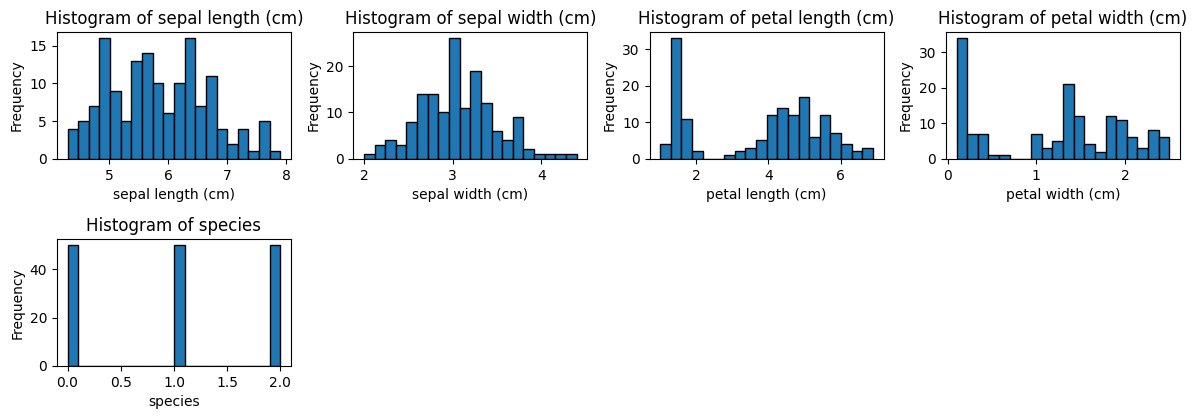

In [9]:
#histogram
plt.figure(figsize=(12,8))
for i, col in enumerate(df, 1):
  plt.subplot(4,4,i)
  plt.hist(df[col], bins=20, edgecolor='black')
  plt.title(f'Histogram of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

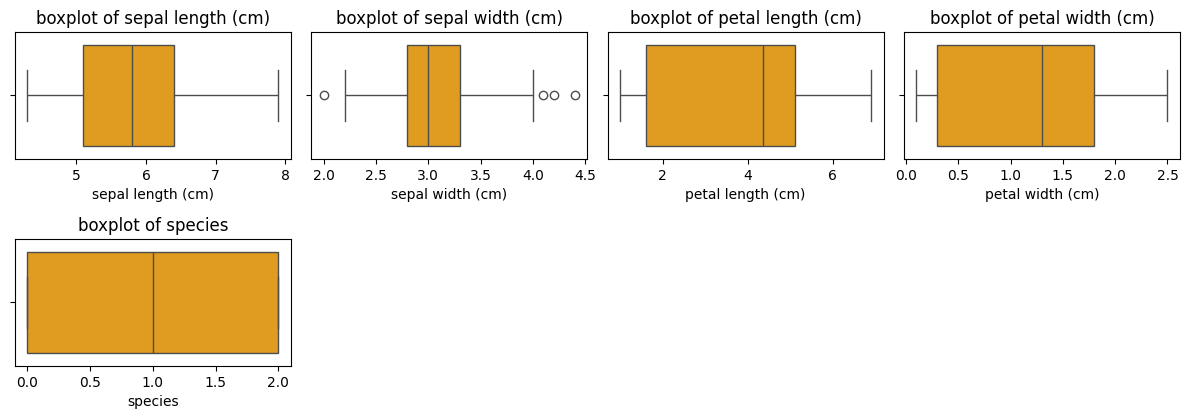

In [10]:
plt.figure(figsize=(12,8))
for i, col in enumerate (df,1):
  plt.subplot(4,4,i)
  sns.boxplot(x=df[col], color='orange')
  plt.title(f'boxplot of {col}')
  plt.xlabel(col)


plt.tight_layout()
plt.show()



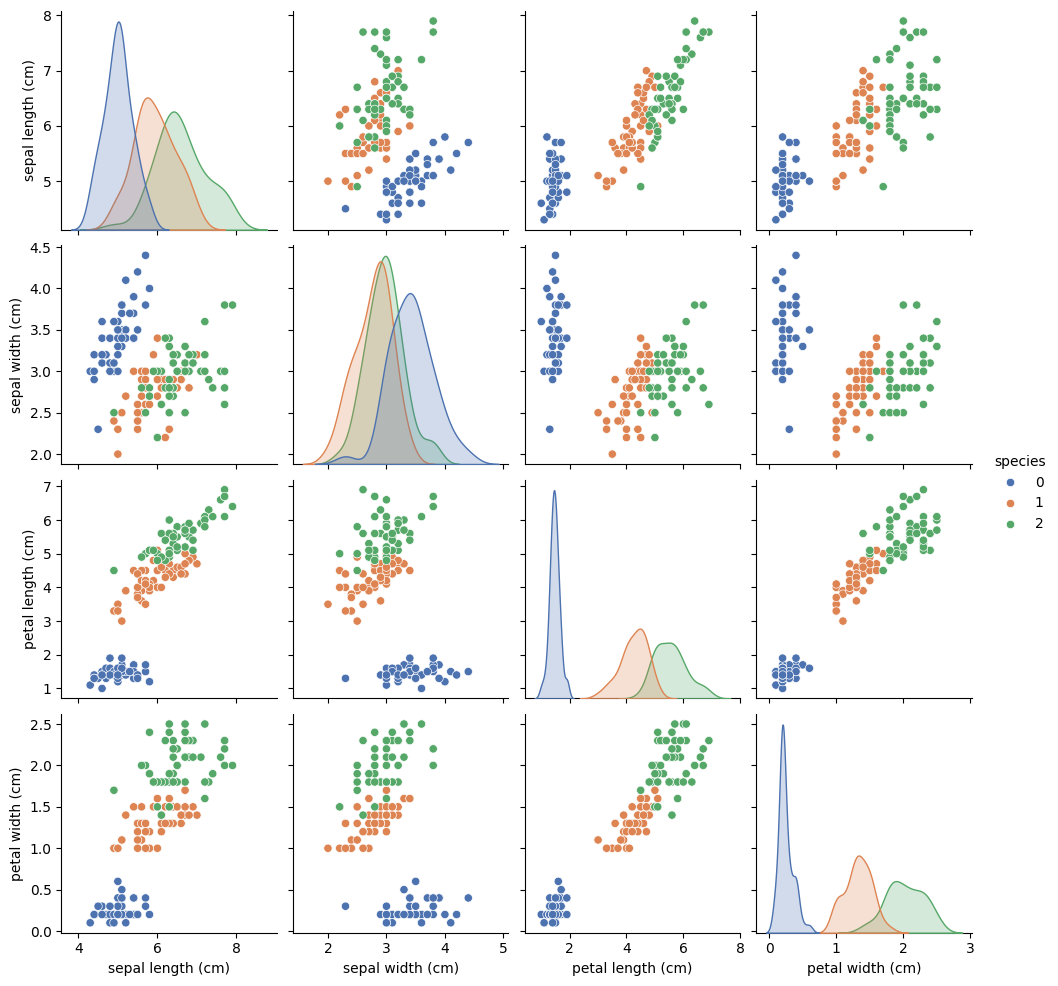

In [11]:
sns.pairplot(df , hue = "species" , diag_kind="kde" , palette="deep" )
plt.show()

In [12]:
# 4.Identify patterns, trends, or anomalies in the data.

df.groupby("species").mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
0,5.006,3.428,1.462,0.246
1,5.936,2.770,4.260,1.326
2,6.588,2.974,5.552,2.026


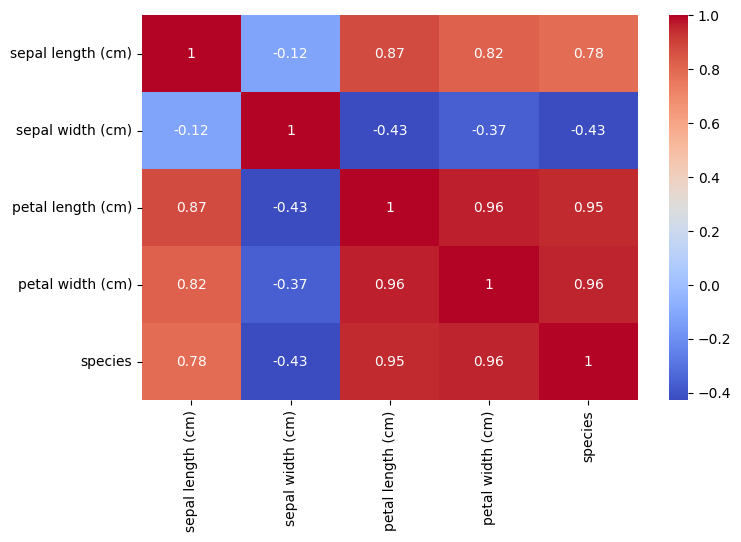

In [13]:
# Correlation Matrix (Trend Identification)

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()


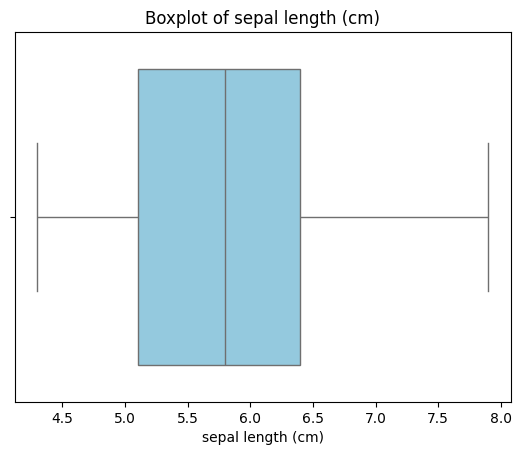

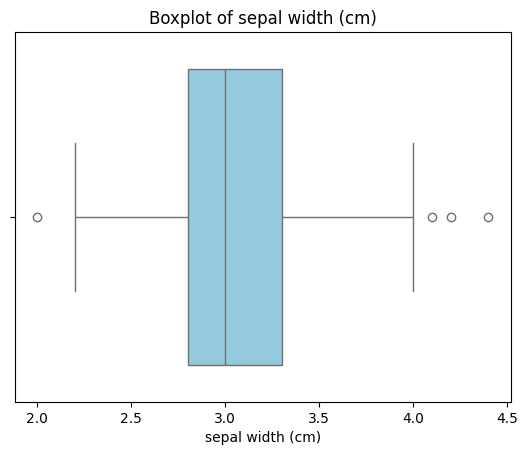

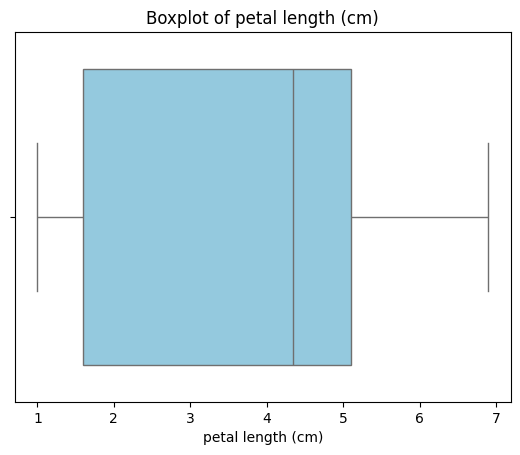

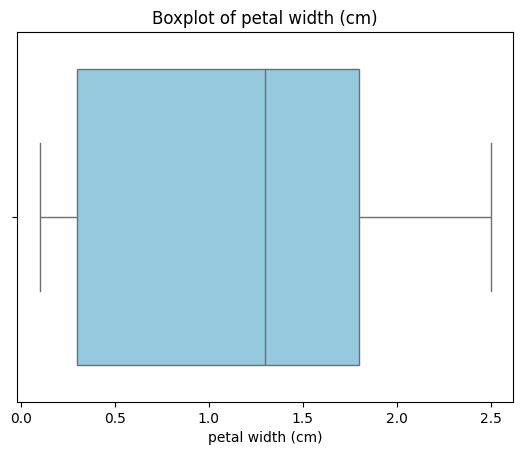

In [14]:
# plt.figure(figsize=(8,5))
for col in df.columns[:-1]:
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Boxplot of {col}")
    plt.show()


In [15]:
# 5.Make basic feature-level inferences from visuals.
# petal length and petal width show strong separation between species, that indicates they are good predictor and sepal features show more overlape and therefor are less use for classification.there is no outliers minor variation in sepal width.